# 당뇨병 여부 분류
1. 데이터 로드
2. train/ valid / test 데이터 분리
3. 파이프라인(결측치 처리 및 정규화)
4. Tensor 변환
5. 미니배치 학습 준비
6. 다층 퍼셉트론 모델 준비
7. Optimizer / Scheduler / EarlyStopping 적용하여 학습
8. 학습 시각화
9. 각종 지표 확인
10. optimizer 여러개 성능 비교
11. K-Fold Cross Validation

- 데이터 셋
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

- y : Outcome  
0 -> 당뇨병 음성    
1 -> 당뇨병 양성

In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tqdm   
# 커널 가상환경에 설치

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader  # Tensor 데이터셋 / 미니배치 로더

import kagglehub            # 캐들 데이터셋 다운로드용
from tqdm.auto import tqdm  # 프로그래스 바

from sklearn.model_selection import train_test_split, StratifiedGroupKFold  # 데이터 분리 / K-Fold 검증
from sklearn.pipeline import Pipeline       # 전처리 과정 통합
from sklearn.impute import SimpleImputer    #
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,average_precision_score,
    confusion_matrix,classification_report
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [4]:
SEED = 42   # 랜덤 시드값
random.seed(SEED)       # 파이썬 랜덤 시드 고정
np.random.seed(SEED)    # numpy 랜덤 시드 고정
torch.manual_seed(SEED) # Pytorch CPU 랜덤 시드 고정


# GPU 가용시
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)    # Pytorch GPU 랜덤 시드 고정


# GPU 기용시 device = 'cuda', dkslaus 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
data_path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

csv_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]
df = pd.read_csv(os.path.join(data_path, csv_files[0]))
print(df.shape)
df

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

|컬럼명|설명|
|---|---|
|Pregnancies|임신 횟수|
|Glucose|포도당 수치|
|BloodPressure|혈압|
|SkinThickness|피부 두께|
|Insulin|인슐린 수치|
|BMI|체질량 지후|
|DiabetesPedigreeFunction|당뇨병 가족력 지표|
|Age|나이|
|Outcome|당뇨병 여부|


,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958


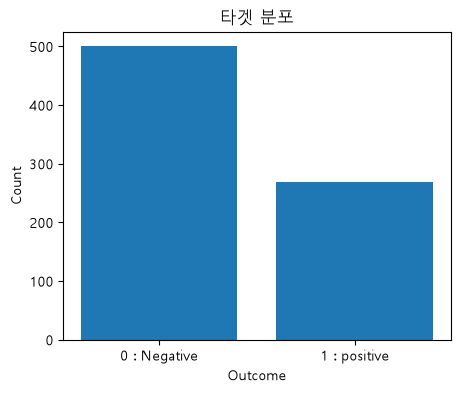

In [7]:
target_counts = df['Outcome'].value_counts().sort_index()               # 클래스별 데이터 갯수
target_ratio = df['Outcome'].value_counts(normalize=True).sort_index()  # 클래스별 비율

# 갯수와 비율을 표로 출력
display(pd.DataFrame({
    'count' : target_counts,
    'ratio' : target_ratio
}))

plt.figure(figsize=(5,4))
plt.bar(['0 : Negative','1 : positive'], target_counts.values)  # 클래스별 갯수 막대그래프
plt.title('타겟 분포')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

### 2. train / valid / test 데이터 분리

In [8]:
X = df.drop(columns= 'Outcome')
y = df['Outcome']

print(X.shape,y.shape)

(768, 8) (768,)


In [9]:
# test데이터를 8:2 비율로 나눈다
X_train_valid,X_test,y_train_valid,y_test = train_test_split(
    X,y,
    test_size= 0.2,
    random_state= SEED,
    stratify= y
)

# 남은 80% 중 8:2 비율로 Train/valid 데이터를 나눈다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,y_train_valid,
    test_size= 0.2,
    random_state= SEED,
    stratify= y_train_valid
)



print(f"X_trian :{X_train.shape},X_valid:{X_valid.shape}X_Test:{X_test.shape}")
print(f"y_trian :{y_train.shape},y_valid:{y_valid.shape}y_Test:{y_test.shape}")

X_trian :(491, 8),X_valid:(123, 8)X_Test:(154, 8)
y_trian :(491,),y_valid:(123,)y_Test:(154,)


### 3. 전처리 파이프라인

In [10]:
preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),    # 결측치가 있다면 중앙값 대체
    ('scaler', StandardScaler())    # 평균 0, 표준편차 1 표준화
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train) # train 데이터는 전처리 기준 학습 / 변환
X_valid_scaled = preprocess_pipeline.transform(X_valid)     # valid 데이터는 학습된 기준으로 변환
X_test_scaled = preprocess_pipeline.transform(X_test)       # test 데이터도 학습된 기준으로 변환


print(X_train_scaled.shape,X_valid_scaled.shape,X_test_scaled.shape)

(491, 8) (123, 8) (154, 8)


### 4. Tensor 형태로 변환

In [11]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor =torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.tensor(y_train.to_numpy(),dtype = torch.float32).reshape(-1,1)
y_valid_tensor = torch.tensor(y_valid.to_numpy(),dtype = torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test.to_numpy(),dtype = torch.float32).reshape(-1,1)

print("X_train_tensor : ",X_train_tensor.size())
print("X_valid_tensor : ", X_valid_tensor.size())
print("X_test_tensor : ", X_test_tensor.size())
print("y_train_tensor : ", y_train_tensor.size())
print("y_valid_tensor : ", y_valid_tensor.size())
print("y_test_tensor : " ,y_test_tensor.size())

X_train_tensor :  torch.Size([491, 8])
X_valid_tensor :  torch.Size([123, 8])
X_test_tensor :  torch.Size([154, 8])
y_train_tensor :  torch.Size([491, 1])
y_valid_tensor :  torch.Size([123, 1])
y_test_tensor :  torch.Size([154, 1])


### 5. 미니배치 학습 준비

In [12]:
BATCH_SIZE =32

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor , y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

# DataLoader를 사용해서 미니배치 단위로 데이터를 나눠 학습
train_loader = DataLoader(
    train_dataset,
    batch_size= BATCH_SIZE,
    shuffle= True
)

# 검증 데이터셋과 테스트 데이터셋을 만들기

valid_loader =  DataLoader(
    valid_dataset,
    batch_size= BATCH_SIZE,
    shuffle= False
)

test_loader =  DataLoader(
    test_dataset,
    batch_size= BATCH_SIZE,
    shuffle= False
)

print(len(train_loader),len(valid_loader),len(test_loader))

16 4 5


### 6. 다층 퍼셉트론 모델 정의

In [13]:
class DiabetesMLP(nn.Module):

    def __init__(self,input_dim,hidden_dims=(64,32,16), dropout=0.2, activation='silu'):
        super().__init__()  # 부모 클래스 초기화

        layers = [] # 신경망 계층을 모두 저장할 리스트
        prev_dim = input_dim    # 이전 계층의 출력 차원

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))   # 배치 정규화 (평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화


            # 활성화 함수 추가 (비선형성 추가)
            if activation =='relu':
                layers.append(nn.ReLU())
            elif activation =='gelu':
                layers.append(nn.GELU())
            elif activation =='silu':
                layers.append(nn.SiLU())
            else:
                raise ValueError("활성화 함수는 relu,gelu,silu 중 하나로 선택해 주세요!")

            layers.append(nn.Dropout(dropout))  # 일부 파라미터 생략 (과적합 완화)
            prev_dim = hidden_dim   
        layers.append(nn.Linear(prev_dim,1))    # 이진 분류 출력 층
        self.net = nn.Sequential(*layers)       # 계층들을 순서대로 연결


    def forward(self,x):
        return self.net(x)

In [14]:
input_dim = X_train_tensor.size(-1)


model = DiabetesMLP(input_dim= input_dim).to(device)

model

DiabetesMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [15]:
# 양성 클래스 비율이 낮을 때 양성 클래스에 더 큰 가중치를 부여하는 손실함수

num_positive = y_train_tensor.sum()                 # 양성 클래스 갯수
num_negative = len(y_train_tensor) - num_positive   # 음성 클래스 갯수
pos_weight = (num_negative / num_positive).to(device)   # 양성 클래스 가중치

print(f"양성 클래스 가중치 : {pos_weight}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # 이진 분류 손실 함수(양성 가중치 부여)

optimizer = torch.optim.Adam( 
    model.parameters(), # 학습할 모델 파라미터
    lr=0.001,           # 학습률
    weight_decay=1e-4   # 가중치 감쇠 (과적합 관화)
)

# 스케줄러 : 학습률을 조정하여 최대한 학습되도록 만드는 도구
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      # 학습률 조정할 최적화 함수
    mode = 'min',   # valid_loss가 작아지는 방향
    factor= 0.5,    # 학습률을 절반으로 감소
    patience= 5     # 개선이 5 epochs 동안 없으면 감소
)



양성 클래스 가중치 : 1.871345043182373


In [16]:
# EarlyStopping : 일정 epoch 동안 성능이 좋아지지 않으면 학습을 멈추는 도구

class EarlyStopping:
    def __init__(self, patience = 20, min_delta = 0.0):
        self.patience = patience    # 개선이 없을때 기다릴 epoch 수
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf     # 현재까지 가장 낮은 valid loss
        self.counter = 0            # 개선이 없던 epoch 수
        self.best_state = None      # 가장 성능이 좋은 모델의 가중치
        self.should_stop = False    # 학습 중단 여부 플래그

    def step(self,valid_loss,model):
        if valid_loss < self.best_loss -self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0


            # 가장 좋은 모델의 가중치 저장
            self.best_state = {
                key : value.detach().cpu().clone() 
                for key,value in model.state_dict().items()
            }

        else:
            self.counter+=1

            # patience 동안 개선이 없을시
            if self.counter >= self.patience:
                self.should_stop = True     # 학습 중단 신호

### 7. Optimizer / Scheduler / EarlyStopping 적용하여 학습

학습 함수와 검증 함수
- 학습 과정
1. 예측값 계산
2. 손실 계산
3. 이전 기울기 초기화
4. 역전파 (기울기 계산)
5. 가중치 업데이트

- 검증 과정에서는 가중치 업데이트를 하지않으므로 torch.no_grad() 사용

In [17]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()       # 학습 모드
    total_loss = 0      # 전체 손실

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)    # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)    # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()           # 이전 step 기울기 초기화
        logits = model(X_batch)         # 예측값 계산
        loss = criterion(logits, y_batch)   # 손실 계산

        loss.backward()     # 기울기 계산
        optimizer.step()    # 가중치 업데이트

        total_loss += loss.item() * len(X_batch)    # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset)    # 데이터 1개당 평균 손실 반환


def evalute_loss(model, data_loader, criterion, device):
    # 평가 모드로 설정
    model.eval() 

    total_loss = 0

    with torch.no_grad():
        for X_batch,y_batch in data_loader:
            X_batch = X_batch.to(device)        # 입력 데이터 장치로 이동
            y_batch = y_batch.to(device)        # 정답 데이터 장치로 이동


            logits = model(X_batch)             # 예측값 계산
            loss = criterion(logits, y_batch)       # 손실값 계산

            total_loss += loss.item() * len(X_batch)# 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset)  # 데이터 1개당 평균손실 반환

In [18]:
EPOCHS = 1000   # 최대 학습 횟수

# 20번 동안 최소 개선 기준 0.0001
early_stopping = EarlyStopping(patience = 20, min_delta = 0.0001)   

history = []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    valid_loss = evalute_loss(model, valid_loader, criterion, device) 

    scheduler.step(valid_loss)      # valid_loss 기준으로 학습률 조정

    current_lr = optimizer.param_groups[0]['lr']    # 현재 학습률 확인

    history.append({
        'epoch':epoch + 1,
        'train_loss' : train_loss,
        'valid_loss' : valid_loss,
        'lr' : current_lr
    })

    early_stopping.step(valid_loss,model)   # Early Stopping 상태 업데이트

    # 20번 동안 개선 없을시 flag True가 되면
    if early_stopping.should_stop:  
        print(f"Epoch {epoch+1}에서 Early Stopping 작동하여 학습 중지!")
        break


if early_stopping.best_state is not None:
    # 가장 성능이 좋은 모델의 가중치 복원
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 81에서 Early Stopping 작동하여 학습 중지!


,epoch,train_loss,valid_loss,lr
0,1,0.843492,0.835091,0.001000
1,2,0.750663,0.701364,0.001000
2,3,0.686309,0.625017,0.001000
3,4,0.677403,0.592671,0.001000
4,5,0.659033,0.563271,0.001000
...,...,...,...,...
76,77,0.412264,0.378113,0.000031
77,78,0.459566,0.373056,0.000031
78,79,0.440943,0.368930,0.000016
79,80,0.438936,0.366871,0.000016


### 8. 학습 시각화

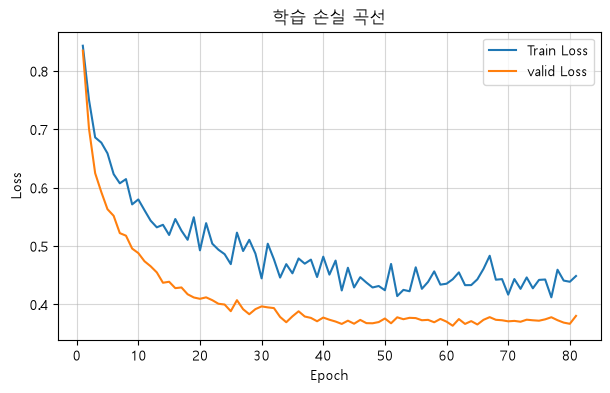

In [19]:
plt.figure(figsize=(7,4))
plt.plot(history_df['epoch'],history_df['train_loss'],label='Train Loss')
plt.plot(history_df['epoch'],history_df['valid_loss'],label='valid Loss')
plt.title('학습 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha =0.5)
plt.show()

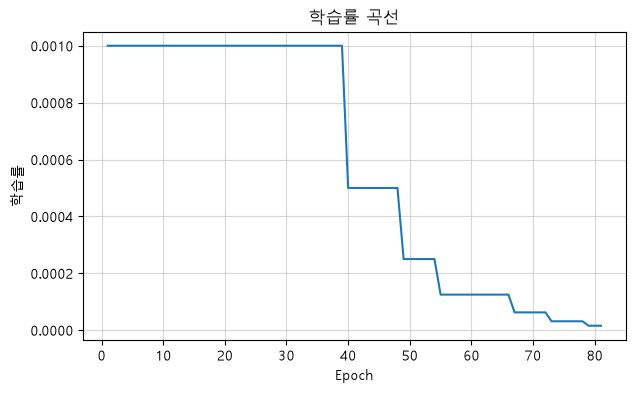

In [20]:
plt.figure(figsize=(7,4))
plt.plot(history_df['epoch'],history_df['lr'])
plt.title('학습률 곡선')
plt.xlabel('Epoch')
plt.ylabel('학습률')
plt.grid(alpha =0.5)
plt.show()

In [22]:
# 실제값과 모델 예측확률을 반환해주는 함수
def predict_proba(model, data_loader, device):
    model.eval()        # 평가 모드
    proba_list = []     # 예측 확률
    target_list = []    # 정답

    # 예측시 기울기 계산 비활성화
    with torch.no_grad():   
        for X_batch,y_batch in data_loader:
            X_batch = X_batch.to(device)    # 입력 데이터만 장치로 이동

            logits = model(X_batch)     # 모델 출력 logits
            proba = torch.sigmoid(logits)   # 양성 클래스 확률로 변환

            proba_list.append(proba.cpu().numpy())  # 예측 확률을 CPU Numpy로 변환해 저장
            target_list.append(y_batch.numpy()) 

    y_proba = np.vstack(proba_list).ravel() # 예측 확률을 1차원으로 변환
    y_true = np.vstack(target_list).ravel() # 정답을 1차원으로 변환

    return y_true,y_proba


- validation 데이터로 threshold(임계값) 확인하고 변경하여 지표 확인
    - 기본 임계값은 0.5
    - 모델의 목적에 따라 임계값을 조정해서 사용하기도한다.
    - 예를 들어 양성 클래스를 더 잘 잡는 걸 목표로 한다면 precision이 좀 낮아지더라도 recall 수치를 우선적으로 높일 수 있다.

In [ ]:
y_valid_true, y_valid_proba = predict_proba(model, valid_loader, device)

thresholds = np.arange(0.1,0.91,0.05)   # 0.1 ~ 0.91 전까지 0.05 텀으로 후보군 생성

threshold_result = []

for threshold in thresholds:
    y_valid_pred = (y_valid_proba >= threshold).astype(int) # 해당 임계값 이상일시 양성(1) 판

    threshold_result.append({
        "threshold" : threshold,
        "accuracy" : accuracy_score(y_valid_true, y_valid_pred),
        "precision" : precision_score(y_valid_true, y_valid_pred),  # 에러발생시 0
        "recall" : recall_score(y_valid_true, y_valid_pred),
        "f1" : f1_score(y_valid_true, y_valid_pred)
    })



threshold_df = pd.DataFrame(threshold_result)
threshold_df.sort_values('f1',ascending= False).head()  # f1스코어 기준 상위 5개

,threshold,accuracy,precision,recall,f1
10,0.60,0.894309,0.812500,0.906977,0.857143
13,0.75,0.902439,0.897436,0.813953,0.853659
12,0.70,0.894309,0.875000,0.813953,0.843373
9,0.55,0.869919,0.754717,0.930233,0.833333
11,0.65,0.878049,0.818182,0.837209,0.827586


In [24]:
best_threshold = threshold_df.sort_values('f1',ascending= False).iloc[0]['threshold']
best_threshold

np.float64(0.6000000000000002)

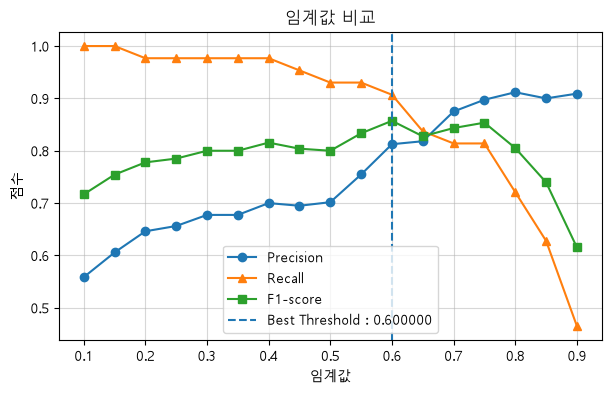

In [26]:
# 임계값 별 지표 시각화

plt.figure(figsize=(7,4))
plt.plot(threshold_df['threshold'],threshold_df['precision'],marker = 'o', label = "Precision")
plt.plot(threshold_df['threshold'],threshold_df['recall'],marker = '^', label = "Recall")
plt.plot(threshold_df['threshold'],threshold_df['f1'],marker = 's', label = "F1-score")
plt.axvline(best_threshold,linestyle = '--', label = f"Best Threshold : {best_threshold:2f}")
plt.title('임계값 비교')
plt.xlabel('임계값')
plt.ylabel('점수')
plt.legend()
plt.grid(alpha =0.5)
plt.show()

In [ ]:
y_test_true, y_test_proba = predict_proba(model, test_loader, device)

y_test_pred = (y_test_proba >= best_threshold).astype(int)  # 해당 임계값 이상일시 양성 (1)판단


test_metrics = {
    "accuracy" : accuracy_score(y_test_true, y_test_pred),
    "precision" : precision_score(y_test_true, y_test_pred, zero_division=0),  # 에러발생시 0
    "recall" : recall_score(y_test_true, y_test_pred, zero_division=0),
    "f1" : f1_score(y_test_true, y_test_pred, zero_division=0),
    'roc_auc' : roc_auc_score(y_test_true, y_test_proba),           # ROC-AUC
    # PR-AUC(AUC지표 중 Precison-Recall 곡선 아래 성능 요약하는 지표)
    'pr_auc' : average_precision_score(y_test_true, y_test_proba)   
}



pd.DataFrame([test_metrics])


,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.863636,0.811321,0.796296,0.803738,0.914259,0.824038


In [30]:
print(classification_report(
    y_test_true,    # 실제값
    y_test_pred,    # 예측값
    target_names=["Negative", "Positive"], # 클래스이름
    zero_division= 0 # 분모 0 나눌시 오류는 0값으로 처리
))



              precision    recall  f1-score   support

    Negative       0.89      0.90      0.90       100
    Positive       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



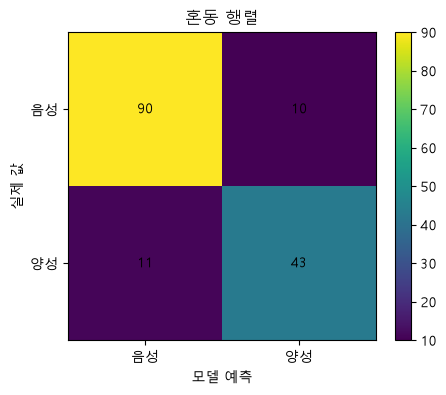

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred) # 혼동 행렬 계싼

plt.figure(figsize=(5,4))   
plt.imshow(cm)              # 혼동 행렬 이미지 표시
plt.title('혼동 행렬')  
plt.xlabel('모델 예측')
plt.ylabel('실제 값')
plt.xticks([0,1],['음성','양성'])
plt.yticks([0,1],['음성','양성'])
plt.colorbar()  # 색상 막대 추가

# 내부 값 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center',va='center')

plt.show()

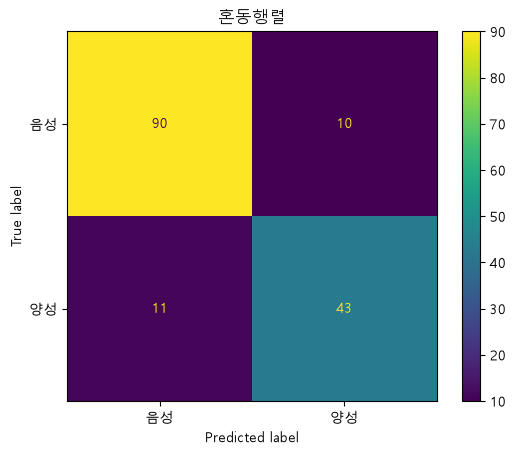

In [33]:
# ConfusionMatrixDisplay 활용

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_true, y_test_pred) # 혼동 행렬 계싼

disp = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels=['음성','양성']
)

disp.plot()
plt.title('혼동행렬')

plt.show()

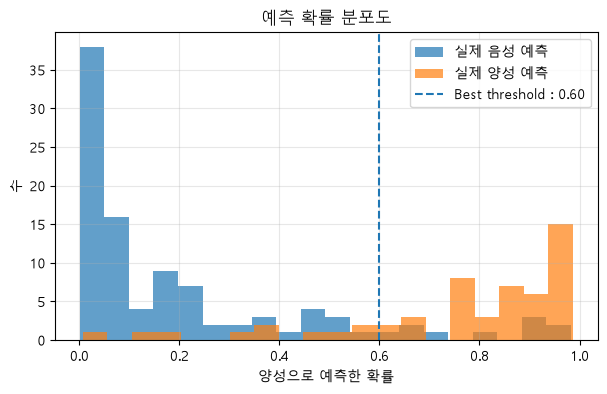

In [38]:
# 예측 확률 분포도

plt.figure(figsize=(7,4))   

plt.hist(y_test_proba[y_test_true == 0], bins=20,alpha = 0.7,label = '실제 음성 예측')
plt.hist(y_test_proba[y_test_true == 1], bins=20,alpha = 0.7,label = '실제 양성 예측')
plt.axvline(best_threshold, linestyle = '--', label = f"Best threshold : {best_threshold:.2f}")
plt.title('예측 확률 분포도')  
plt.xlabel('양성으로 예측한 확률')
plt.ylabel('수')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [39]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [51]:
# 샘플 데이터로 예측해보기
sample = pd.DataFrame([{
    'Pregnancies' : 2,
    'Glucose' : 160,
    'BloodPressure' : 70,
    'SkinThickness' : 25,
    'Insulin' : 50,
    'BMI' : 30,
    'DiabetesPedigreeFunction' : 1,
    'Age' : 35

}])
sample_scaled = preprocess_pipeline.transform(sample)
sample_tensor = torch.FloatTensor(sample_scaled).to(device)

model.eval()
with torch.no_grad():
    logit = model(sample_tensor)
    proba = torch.sigmoid(logit).item()
    pred = int(proba >= best_threshold)


print(f"양성 클래스일 확률 : {proba:4f}, 예측 클래스 : {pred}")

양성 클래스일 확률 : 0.331927, 예측 클래스 : 0
